In [212]:
import numpy as np
import pandas as pd
import datetime as dt
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_style(style='whitegrid')
sns.set_theme(rc={'figure.figsize':(11.7,8.27)})
pd.set_option('display.max_columns', 200)

In [213]:
df = pd.read_csv("../data/processed1/valid_selection.csv")

In [214]:
df.head()

,datetime,household_ID,branch,sub_type,date,time,consumption,Heating_Cooking,wave,Communication_IT,Mobility_Energy,Cooling_Refrigeration,Cleaning_Household,Security_Infrastructure,Entertainment_ICT,Other,total_appliances,high_energy_appliances,cooling_ratio,digital_lifestyle,appliance_diversity,household_size,avg_age,max_age,num_children,num_adults,num_elderly,num_employed,avg_hours_home,dependency_ratio,employment_ratio
0,2023-12-09 05:49:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-09,05:49,2.5330,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0
1,2023-12-09 22:52:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-09,22:52,2.3300,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0
2,2023-12-10 05:49:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-10,05:49,1.4720,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0
3,2023-12-10 18:49:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-10,18:49,1.9111,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0
4,2023-12-11 05:48:00,ID0013,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-11,05:48,2.3949,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0


In [215]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
consumption,470083.0,73.139946,1144.945880,0.0,0.594000,1.577000,3.540000,36920.053
Heating_Cooking,470083.0,4.107634,2.984012,0.0,2.000000,3.000000,6.000000,17.000
wave,470083.0,1.057920,0.247262,1.0,1.000000,1.000000,1.000000,3.000
Communication_IT,470083.0,0.913256,1.194438,0.0,0.000000,0.000000,2.000000,7.000
Mobility_Energy,470083.0,0.124929,0.410766,0.0,0.000000,0.000000,0.000000,3.000
Cooling_Refrigeration,470083.0,1.787182,0.806352,0.0,1.000000,2.000000,2.000000,6.000
Cleaning_Household,470083.0,1.317640,1.386870,0.0,0.000000,1.000000,2.000000,10.000
Security_Infrastructure,470083.0,0.382079,1.084141,0.0,0.000000,0.000000,0.000000,8.000
Entertainment_ICT,470083.0,5.651238,2.879820,0.0,4.000000,5.000000,7.000000,25.000
Other,470083.0,0.460970,1.097700,0.0,0.000000,0.000000,0.000000,12.000


In [216]:
df['date'] = pd.to_datetime(df['date'])

In [217]:
df['datetime'] = pd.to_datetime(df['datetime'])

In [218]:
df = df.sort_values(['household_ID', 'datetime'])

In [219]:
df = df.dropna(subset=['consumption'])

In [220]:
df = df.set_index('datetime')

In [221]:
df_resampled = (
    df
    .groupby('household_ID')
    .resample('6h')
    .agg({
        'consumption': 'last',
        'branch': 'first',
        'sub_type': 'first'
    })
)

In [222]:
df_resampled = (
    df
    .groupby('household_ID')
    .resample('6h')
    .last()
)

In [223]:
df = df.reset_index()

In [224]:
df = (
    df
    .sort_values(['household_ID', 'datetime'])
    .set_index('datetime')
    .groupby('household_ID')
    .resample('6h')
    .last()
    .drop(columns=['household_ID'], errors='ignore')
    .reset_index()
)

In [225]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


df = df.sort_values(['household_ID', 'datetime'])
daily_series = df.groupby('datetime')['consumption'].mean()
daily_series = daily_series.sort_index().dropna()

<Figure size 1000x500 with 0 Axes>

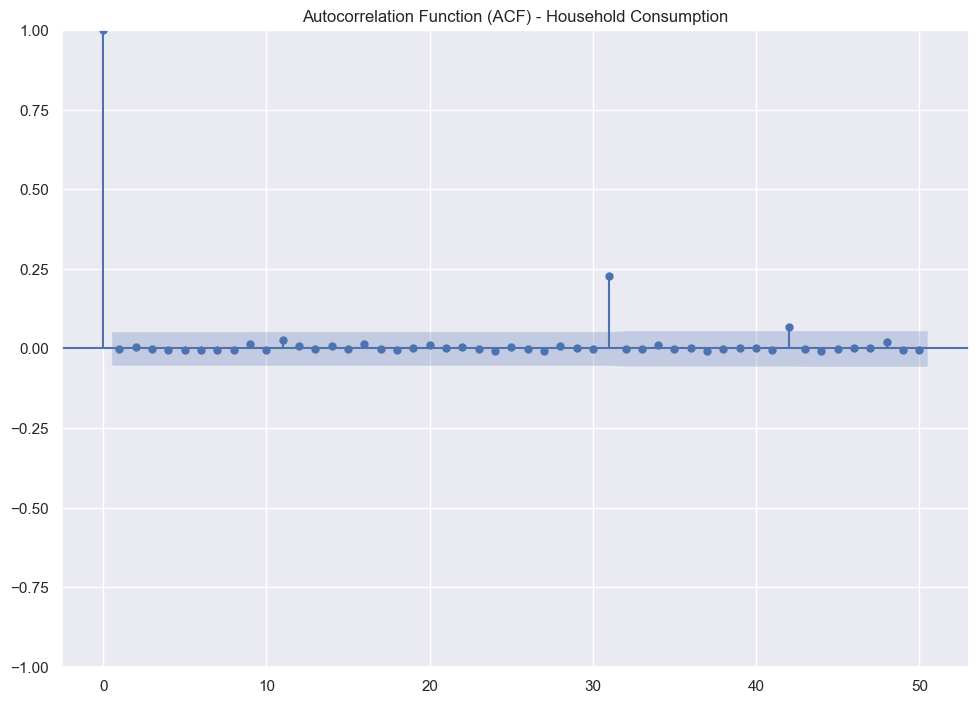

In [226]:
plt.figure(figsize=(10,5))
plot_acf(daily_series, lags=50)
plt.title("Autocorrelation Function (ACF) - Household Consumption")
plt.show()

<Figure size 1000x500 with 0 Axes>

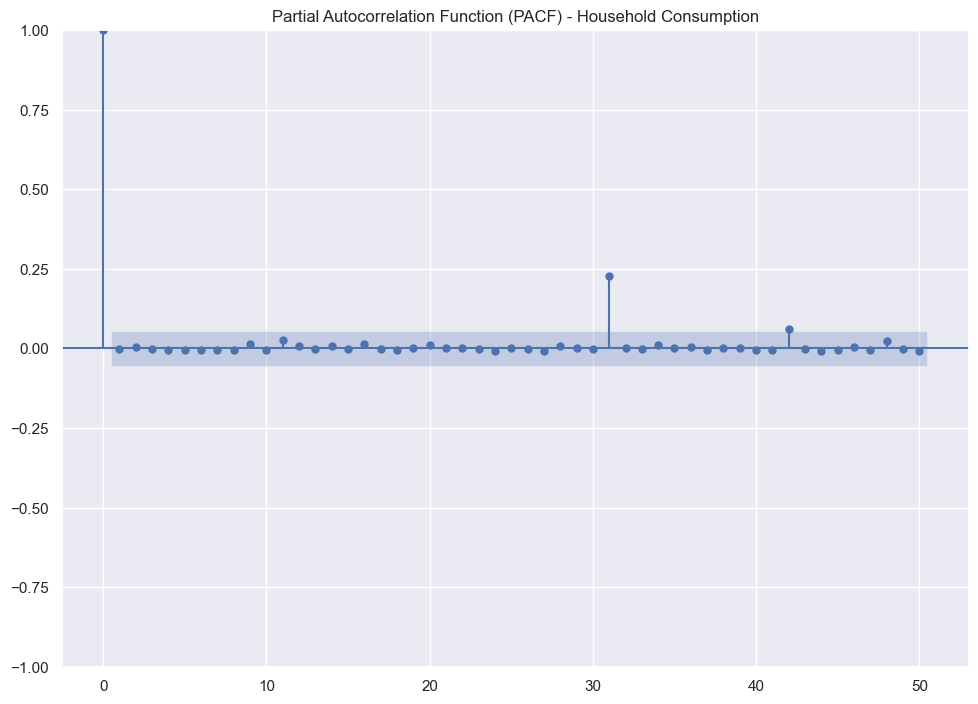

In [227]:
plt.figure(figsize=(10,5))
plot_pacf(daily_series, lags=50, method='ywm')
plt.title("Partial Autocorrelation Function (PACF) - Household Consumption")
plt.show()

In [228]:
df.head()

,household_ID,datetime,branch,sub_type,date,time,consumption,Heating_Cooking,wave,Communication_IT,Mobility_Energy,Cooling_Refrigeration,Cleaning_Household,Security_Infrastructure,Entertainment_ICT,Other,total_appliances,high_energy_appliances,cooling_ratio,digital_lifestyle,appliance_diversity,household_size,avg_age,max_age,num_children,num_adults,num_elderly,num_employed,avg_hours_home,dependency_ratio,employment_ratio
0,ID0013,2023-12-09 00:00:00,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-09,05:49,2.533,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0
1,ID0013,2023-12-09 06:00:00,None,None,NaT,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ID0013,2023-12-09 12:00:00,None,None,NaT,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ID0013,2023-12-09 18:00:00,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-09,22:52,2.330,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0
4,ID0013,2023-12-10 00:00:00,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-10,05:49,1.472,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0


In [229]:
survey_cols = [
    'branch',
    'sub_type',
    'Heating_Cooking',
    'wave',
    'Communication_IT',
    'Mobility_Energy',
    'Cooling_Refrigeration',
    'Cleaning_Household',
    'Security_Infrastructure',
    'Entertainment_ICT',
    'Other',
    'total_appliances',
    'high_energy_appliances',
    'cooling_ratio',
    'digital_lifestyle',
    'appliance_diversity',
    'household_size',
    'avg_age',
    'max_age',
    'num_children',
    'num_adults',
    'num_elderly',
    'num_employed',
    'avg_hours_home',
    'dependency_ratio',
    'employment_ratio'
]

df[survey_cols] = (
    df.groupby('household_ID')[survey_cols].ffill()
)

In [230]:
df.head()

,household_ID,datetime,branch,sub_type,date,time,consumption,Heating_Cooking,wave,Communication_IT,Mobility_Energy,Cooling_Refrigeration,Cleaning_Household,Security_Infrastructure,Entertainment_ICT,Other,total_appliances,high_energy_appliances,cooling_ratio,digital_lifestyle,appliance_diversity,household_size,avg_age,max_age,num_children,num_adults,num_elderly,num_employed,avg_hours_home,dependency_ratio,employment_ratio
0,ID0013,2023-12-09 00:00:00,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-09,05:49,2.533,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0
1,ID0013,2023-12-09 06:00:00,NUGEGODA,Anteleco - DLMS SinglePhase,NaT,None,NaN,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0
2,ID0013,2023-12-09 12:00:00,NUGEGODA,Anteleco - DLMS SinglePhase,NaT,None,NaN,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0
3,ID0013,2023-12-09 18:00:00,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-09,22:52,2.330,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0
4,ID0013,2023-12-10 00:00:00,NUGEGODA,Anteleco - DLMS SinglePhase,2023-12-10,05:49,1.472,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0


Label encoding was applied to categorical variables such as branch and sub_type to convert them into numerical representations suitable for tree-based machine learning models, while preserving category distinctions.

In [231]:
from sklearn.preprocessing import LabelEncoder

le_branch = LabelEncoder()
le_subtype = LabelEncoder()

df['branch_encoded'] = le_branch.fit_transform(df['branch'])
df['sub_type_encoded'] = le_subtype.fit_transform(df['sub_type'])

In [232]:
df = df.drop(columns=['branch', 'sub_type'])

In [233]:
df.head()

,household_ID,datetime,date,time,consumption,Heating_Cooking,wave,Communication_IT,Mobility_Energy,Cooling_Refrigeration,Cleaning_Household,Security_Infrastructure,Entertainment_ICT,Other,total_appliances,high_energy_appliances,cooling_ratio,digital_lifestyle,appliance_diversity,household_size,avg_age,max_age,num_children,num_adults,num_elderly,num_employed,avg_hours_home,dependency_ratio,employment_ratio,branch_encoded,sub_type_encoded
0,ID0013,2023-12-09 00:00:00,2023-12-09,05:49,2.533,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0,4,1
1,ID0013,2023-12-09 06:00:00,NaT,None,NaN,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0,4,1
2,ID0013,2023-12-09 12:00:00,NaT,None,NaN,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0,4,1
3,ID0013,2023-12-09 18:00:00,2023-12-09,22:52,2.330,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0,4,1
4,ID0013,2023-12-10 00:00:00,2023-12-10,05:49,1.472,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0,4,1


In [234]:
df = df.set_index('datetime')

In [235]:
df = df.sort_values(['household_ID', 'datetime'])

In [236]:
df['consumption'] = df.groupby('household_ID')['consumption'].transform(lambda x: x.interpolate(method='time'))

In [237]:
df = df.reset_index()

In [238]:
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [239]:
df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)

In [240]:
df = df.sort_values(['household_ID', 'datetime'])

df['lag_1'] = df.groupby('household_ID')['consumption'].shift(1)
df['lag_4'] = df.groupby('household_ID')['consumption'].shift(4)   # 24 hrs
df['lag_28'] = df.groupby('household_ID')['consumption'].shift(28) # 1 week before

In [241]:
df['rolling_mean_4'] = df.groupby('household_ID')['consumption']\
    .transform(lambda x: x.shift(1).rolling(4).mean())

df['rolling_mean_28'] = df.groupby('household_ID')['consumption']\
    .transform(lambda x: x.shift(1).rolling(28).mean())

df['rolling_std_4'] = df.groupby('household_ID')['consumption']\
    .transform(lambda x: x.shift(1).rolling(4).std())

In [242]:
df.head()

,datetime,household_ID,date,time,consumption,Heating_Cooking,wave,Communication_IT,Mobility_Energy,Cooling_Refrigeration,Cleaning_Household,Security_Infrastructure,Entertainment_ICT,Other,total_appliances,high_energy_appliances,cooling_ratio,digital_lifestyle,appliance_diversity,household_size,avg_age,max_age,num_children,num_adults,num_elderly,num_employed,avg_hours_home,dependency_ratio,employment_ratio,branch_encoded,sub_type_encoded,hour,day_of_week,day,month,is_weekend,hour_sin,hour_cos,lag_1,lag_4,lag_28,rolling_mean_4,rolling_mean_28,rolling_std_4
0,2023-12-09 00:00:00,ID0013,2023-12-09,05:49,2.533000,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0,4,1,0,5,9,12,1,0.000000e+00,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-12-09 06:00:00,ID0013,NaT,None,2.465333,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0,4,1,6,5,9,12,1,1.000000e+00,6.123234e-17,2.533000,NaN,NaN,NaN,NaN,NaN
2,2023-12-09 12:00:00,ID0013,NaT,None,2.397667,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0,4,1,12,5,9,12,1,1.224647e-16,-1.000000e+00,2.465333,NaN,NaN,NaN,NaN,NaN
3,2023-12-09 18:00:00,ID0013,2023-12-09,22:52,2.330000,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0,4,1,18,5,9,12,1,-1.000000e+00,-1.836970e-16,2.397667,NaN,NaN,NaN,NaN,NaN
4,2023-12-10 00:00:00,ID0013,2023-12-10,05:49,1.472000,3.0,1.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,5.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0,4,1,0,6,10,12,1,0.000000e+00,1.000000e+00,2.330000,2.533,NaN,2.4315,NaN,0.087357


In [243]:
df = df.dropna(subset=[
    'lag_1','lag_4','lag_28',
    'rolling_mean_4','rolling_mean_28','rolling_std_4'
])

In [244]:
drop_cols = ['date', 'time', 'wave', 'appliance_diversity']  # redundant
df = df.drop(columns=drop_cols)

In [245]:
drop_cols = ['cooling_ratio', 'digital_lifestyle', 'dependency_ratio']


In [246]:
df.head()

,datetime,household_ID,consumption,Heating_Cooking,Communication_IT,Mobility_Energy,Cooling_Refrigeration,Cleaning_Household,Security_Infrastructure,Entertainment_ICT,Other,total_appliances,high_energy_appliances,cooling_ratio,digital_lifestyle,household_size,avg_age,max_age,num_children,num_adults,num_elderly,num_employed,avg_hours_home,dependency_ratio,employment_ratio,branch_encoded,sub_type_encoded,hour,day_of_week,day,month,is_weekend,hour_sin,hour_cos,lag_1,lag_4,lag_28,rolling_mean_4,rolling_mean_28,rolling_std_4
28,2023-12-16 00:00:00,ID0013,2.582,3.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0,4,1,0,5,16,12,1,0.000000e+00,1.000000e+00,2.795,2.253900,2.533000,2.524450,2.366214,0.232852
29,2023-12-16 06:00:00,ID0013,2.519,3.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0,4,1,6,5,16,12,1,1.000000e+00,6.123234e-17,2.582,2.434267,2.465333,2.606475,2.367964,0.148170
30,2023-12-16 12:00:00,ID0013,2.456,3.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0,4,1,12,5,16,12,1,1.224647e-16,-1.000000e+00,2.519,2.614633,2.397667,2.627658,2.369881,0.118412
31,2023-12-16 18:00:00,ID0013,2.393,3.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0,4,1,18,5,16,12,1,-1.000000e+00,-1.836970e-16,2.456,2.795000,2.330000,2.588000,2.371964,0.147275
32,2023-12-17 00:00:00,ID0013,2.480,3.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0,4,1,0,6,17,12,1,0.000000e+00,1.000000e+00,2.393,2.582000,1.472000,2.487500,2.374214,0.081333


In [247]:
df.tail()

,datetime,household_ID,consumption,Heating_Cooking,Communication_IT,Mobility_Energy,Cooling_Refrigeration,Cleaning_Household,Security_Infrastructure,Entertainment_ICT,Other,total_appliances,high_energy_appliances,cooling_ratio,digital_lifestyle,household_size,avg_age,max_age,num_children,num_adults,num_elderly,num_employed,avg_hours_home,dependency_ratio,employment_ratio,branch_encoded,sub_type_encoded,hour,day_of_week,day,month,is_weekend,hour_sin,hour_cos,lag_1,lag_4,lag_28,rolling_mean_4,rolling_mean_28,rolling_std_4
1175101,2024-12-30 00:00:00,ID3804,0.2010,7.0,1.0,0.0,2.0,2.0,0.0,5.0,3.0,17.0,11.0,0.117647,6.0,5.0,32.4,67.0,2.0,3.0,1.0,1.0,136.2,0.6,0.2,4,1,0,0,30,12,0,0.000000e+00,1.000000e+00,1.45775,5.22800,6.6100,3.342875,5.342218,1.622457
1175102,2024-12-30 06:00:00,ID3804,1.9295,7.0,1.0,0.0,2.0,2.0,0.0,5.0,3.0,17.0,11.0,0.117647,6.0,5.0,32.4,67.0,2.0,3.0,1.0,1.0,136.2,0.6,0.2,4,1,6,0,30,12,0,1.000000e+00,6.123234e-17,0.20100,3.97125,6.6515,2.086125,5.113325,1.622457
1175103,2024-12-30 12:00:00,ID3804,3.6580,7.0,1.0,0.0,2.0,2.0,0.0,5.0,3.0,17.0,11.0,0.117647,6.0,5.0,32.4,67.0,2.0,3.0,1.0,1.0,136.2,0.6,0.2,4,1,12,0,30,12,0,1.224647e-16,-1.000000e+00,1.92950,2.71450,6.6930,1.575688,4.944682,1.052893
1175104,2024-12-30 18:00:00,ID3804,5.3865,7.0,1.0,0.0,2.0,2.0,0.0,5.0,3.0,17.0,11.0,0.117647,6.0,5.0,32.4,67.0,2.0,3.0,1.0,1.0,136.2,0.6,0.2,4,1,18,0,30,12,0,-1.000000e+00,-1.836970e-16,3.65800,1.45775,6.7345,1.811562,4.836289,1.430890
1175105,2024-12-31 00:00:00,ID3804,7.1150,7.0,1.0,0.0,2.0,2.0,0.0,5.0,3.0,17.0,11.0,0.117647,6.0,5.0,32.4,67.0,2.0,3.0,1.0,1.0,136.2,0.6,0.2,4,1,0,1,31,12,0,0.000000e+00,1.000000e+00,5.38650,0.20100,6.7760,2.793750,4.788146,2.231484


Household identifiers were one-hot encoded to capture household-specific consumption patterns without introducing ordinal relationships between categories.

In [248]:
# df = pd.get_dummies(df, columns=['household_id'], drop_first=True)

Household identifiers were label encoded later to capture household-specific consumption patterns without introducing ordinal relationships between categories.

In [249]:
le_house = LabelEncoder()
df['household_id_encoded'] = le_house.fit_transform(df['household_ID'])

In [250]:
df = df.drop(columns=['household_ID'])

In [251]:
df.head()

,datetime,consumption,Heating_Cooking,Communication_IT,Mobility_Energy,Cooling_Refrigeration,Cleaning_Household,Security_Infrastructure,Entertainment_ICT,Other,total_appliances,high_energy_appliances,cooling_ratio,digital_lifestyle,household_size,avg_age,max_age,num_children,num_adults,num_elderly,num_employed,avg_hours_home,dependency_ratio,employment_ratio,branch_encoded,sub_type_encoded,hour,day_of_week,day,month,is_weekend,hour_sin,hour_cos,lag_1,lag_4,lag_28,rolling_mean_4,rolling_mean_28,rolling_std_4,household_id_encoded
28,2023-12-16 00:00:00,2.582,3.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0,4,1,0,5,16,12,1,0.000000e+00,1.000000e+00,2.795,2.253900,2.533000,2.524450,2.366214,0.232852,0
29,2023-12-16 06:00:00,2.519,3.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0,4,1,6,5,16,12,1,1.000000e+00,6.123234e-17,2.582,2.434267,2.465333,2.606475,2.367964,0.148170,0
30,2023-12-16 12:00:00,2.456,3.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0,4,1,12,5,16,12,1,1.224647e-16,-1.000000e+00,2.519,2.614633,2.397667,2.627658,2.369881,0.118412,0
31,2023-12-16 18:00:00,2.393,3.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0,4,1,18,5,16,12,1,-1.000000e+00,-1.836970e-16,2.456,2.795000,2.330000,2.588000,2.371964,0.147275,0
32,2023-12-17 00:00:00,2.480,3.0,1.0,0.0,2.0,1.0,0.0,3.0,0.0,10.0,6.0,0.2,4.0,1.0,75.0,75.0,0.0,1.0,1.0,0.0,168.0,1.0,0.0,4,1,0,6,17,12,1,0.000000e+00,1.000000e+00,2.393,2.582000,1.472000,2.487500,2.374214,0.081333,0


In [252]:
df.to_csv("../data/processed1/final_selection.csv", index=False)

In [253]:
df.groupby('household_id_encoded')['datetime'].diff().value_counts().head()

datetime
0 days 06:00:00    1139755
Name: count, dtype: int64